# Algoritmo BT-FC-DO para Coloreado de Grafos (CSP)

**BT-FC-DO** = *Backtracking* + *Forward Checking* + *Ordenamiento Dinámico* (Dynamic Ordering).

Este cuaderno resuelve el **Problema de Satisfacción de Restricciones (CSP)** de **coloreado de grafos**:

- **Variables:** los nodos del grafo (0, 1, ..., N-1).
- **Dominios:** el conjunto de colores disponibles `{0, 1, ..., k-1}` para cada nodo.
- **Restricciones:** dos nodos adyacentes (conectados por una arista) no pueden tener el mismo color.

El algoritmo combina tres técnicas clásicas de búsqueda con restricciones:

1. **Backtracking (BT):** búsqueda en profundidad con retroceso cuando una asignación viola una restricción o agota su dominio.
2. **Forward Checking (FC):** cada vez que se asigna un color a una variable, se eliminan de los dominios de las variables **vecinas aún no asignadas** los valores que ya no son consistentes. Si el dominio de algún vecino queda vacío, se detecta el fallo *antes* de seguir profundizando (poda temprana).
3. **Ordenamiento Dinámico (DO):** en cada paso se elige la **próxima variable** a asignar usando la heurística **MRV** (*Minimum Remaining Values*: la variable con menos valores posibles en su dominio), y como desempate la **heurística de grado** (la variable con más vecinos aún no asignados). Esto tiende a detectar los fallos lo antes posible y reduce el árbol de búsqueda.

## Estructura del cuaderno
1. Definición del grafo (lectura desde archivo `.txt` o generación aleatoria).
2. Implementación comentada del algoritmo `BT-FC-DO`.
3. Búsqueda del coloreado (con k fijo o buscando el número cromático mínimo).
4. Visualización del grafo con los nodos coloreados.

## 1. Importación de librerías

In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt
import networkx as nx

# Semilla opcional para reproducibilidad de los ejemplos aleatorios
random.seed(None)


## 2. Definición del grafo

El grafo se representa mediante una **matriz de adyacencia** simétrica de tamaño `N x N` (con `N < 21`):
- `matriz[i][j] = 1` si los nodos `i` y `j` están conectados.
- `matriz[i][j] = 0` si no lo están.
- La diagonal siempre es `0` (un nodo no es adyacente a sí mismo).

Se ofrecen dos formas de obtener la matriz:

### 2.1 Lectura desde un archivo de texto plano (.txt)
El archivo debe contener la matriz de adyacencia como números separados por espacios, una fila por línea. Ejemplo para N=5:
```
0 1 0 1 0
1 0 1 0 0
0 1 0 1 1
1 0 1 0 1
0 0 1 1 0
```

### 2.2 Generación aleatoria
Se genera una matriz simétrica aleatoria de tamaño `N`, incluyendo cada arista `(i, j)` con una probabilidad `prob_arista`.

In [2]:
def leer_matriz_desde_archivo(ruta):
    """
    Lee una matriz de adyacencia desde un archivo de texto plano (.txt).
    Cada línea del archivo representa una fila de la matriz, con los
    valores (0 o 1) separados por espacios.

    Parámetros:
        ruta (str): ruta al archivo .txt

    Retorna:
        np.ndarray: matriz de adyacencia (N x N), validada como
                    cuadrada, simétrica y con diagonal en cero.
    """
    with open(ruta, 'r') as f:
        lineas = [linea.strip() for linea in f if linea.strip() != ""]

    matriz = np.array([[int(x) for x in linea.split()] for linea in lineas])

    n = matriz.shape[0]
    assert matriz.shape[0] == matriz.shape[1], "La matriz debe ser cuadrada (N x N)."
    assert n < 21, "El tamaño N debe ser menor que 21."
    assert np.array_equal(matriz, matriz.T), "La matriz debe ser simétrica."
    assert np.all(np.diag(matriz) == 0), "La diagonal debe contener solo ceros."
    assert set(np.unique(matriz)).issubset({0, 1}), "La matriz solo debe contener 0 y 1."

    return matriz


def generar_matriz_aleatoria(n, prob_arista=0.3, semilla=None):
    """
    Genera una matriz de adyacencia simétrica aleatoria de tamaño n x n.

    Parámetros:
        n (int): número de nodos (debe ser < 21).
        prob_arista (float): probabilidad de que exista una arista entre
                              cada par de nodos (0.0 a 1.0).
        semilla (int, opcional): semilla para reproducibilidad.

    Retorna:
        np.ndarray: matriz de adyacencia (n x n) simétrica, con diagonal en 0.
    """
    assert n < 21, "El tamaño N debe ser menor que 21."
    if semilla is not None:
        random.seed(semilla)

    matriz = np.zeros((n, n), dtype=int)
    for i in range(n):
        for j in range(i + 1, n):
            if random.random() < prob_arista:
                matriz[i][j] = 1
                matriz[j][i] = 1  # se mantiene la simetría
    return matriz


def guardar_matriz_en_archivo(matriz, ruta):
    """Utilidad auxiliar: guarda una matriz de adyacencia en un archivo .txt."""
    with open(ruta, 'w') as f:
        for fila in matriz:
            f.write(' '.join(str(int(v)) for v in fila) + '\n')


### 2.3 Selección del grafo a utilizar

Elija **una** de las dos opciones ejecutando la celda correspondiente. Por defecto se genera un grafo aleatorio de `N = 10` nodos.

In [37]:
# --------- OPCIÓN A: Generar un grafo aleatorio ---------
N = 9                 # número de nodos (N < 21)
PROB_ARISTA = 0.35      # probabilidad de arista entre cada par de nodos
SEMILLA = None           # usar None para un grafo distinto en cada ejecución

matriz_adyacencia = generar_matriz_aleatoria(N, prob_arista=PROB_ARISTA, semilla=SEMILLA)

print(f"Grafo aleatorio generado con N = {N} nodos:")
print(matriz_adyacencia)


Grafo aleatorio generado con N = 9 nodos:
[[0 0 1 0 0 0 0 1 0]
 [0 0 1 0 0 1 0 0 1]
 [1 1 0 0 0 0 0 1 1]
 [0 0 0 0 1 0 0 0 1]
 [0 0 0 1 0 1 0 0 1]
 [0 1 0 0 1 0 0 1 0]
 [0 0 0 0 0 0 0 0 1]
 [1 0 1 0 0 1 0 0 0]
 [0 1 1 1 1 0 1 0 0]]


In [38]:
# --------- OPCIÓN B: Leer el grafo desde un archivo .txt ---------
# Descomente y ajuste la ruta para usar esta opción en lugar de la anterior.

# ruta_archivo = "grafo.txt"
# matriz_adyacencia = leer_matriz_desde_archivo(ruta_archivo)
# print("Grafo leído desde archivo:")
# print(matriz_adyacencia)


## 3. Algoritmo BT-FC-DO (comentado)

La clase `ColoreadoGrafoCSP` modela el problema y ejecuta la búsqueda:

- `seleccionar_variable`: implementa el **Ordenamiento Dinámico (DO)** — heurística MRV con desempate por grado.
- `forward_checking` / `deshacer_forward_checking`: implementan el **Forward Checking (FC)**, incluyendo el mecanismo para deshacer las podas al retroceder.
- `bt_fc_do`: implementa el **Backtracking (BT)** recursivo, integrando FC y DO en cada paso.

También se registran estadísticas de desempeño (nodos explorados y retrocesos) para analizar la eficiencia de la búsqueda.

In [39]:
class ColoreadoGrafoCSP:
    """
    Resuelve el problema de coloreado de grafos como un CSP, usando el
    algoritmo BT-FC-DO (Backtracking + Forward Checking + Ordenamiento
    Dinámico de variables).
    """

    def __init__(self, matriz_adyacencia, num_colores):
        """
        Parámetros:
            matriz_adyacencia (np.ndarray): matriz NxN simétrica (0/1).
            num_colores (int): número de colores (k) disponibles, es decir,
                                el tamaño del dominio de cada variable.
        """
        self.matriz = matriz_adyacencia
        self.n = matriz_adyacencia.shape[0]        # número de nodos (variables)
        self.k = num_colores                        # tamaño del dominio (colores)

        # Lista de adyacencia: vecinos[i] = lista de nodos conectados a i
        self.vecinos = {
            i: [j for j in range(self.n) if matriz_adyacencia[i][j] == 1 and j != i]
            for i in range(self.n)
        }

        # Estadísticas de la búsqueda (útiles para analizar el rendimiento)
        self.nodos_explorados = 0
        self.retrocesos = 0

    # ------------------------------------------------------------------
    def dominios_iniciales(self):
        """Cada variable (nodo) inicia con el dominio completo de colores {0,...,k-1}."""
        return {i: set(range(self.k)) for i in range(self.n)}

    # ------------------------------------------------------------------
    def seleccionar_variable(self, dominios, asignados):
        """
        ORDENAMIENTO DINÁMICO (DO):
        Selecciona la próxima variable no asignada a partir de:
          1. Heurística MRV (Minimum Remaining Values): se prioriza la
             variable cuyo dominio actual tiene MENOS valores posibles,
             ya que es la más restringida y la más probable de fallar
             (conviene detectar el fallo cuanto antes).
          2. Heurística de grado (desempate): entre las variables con
             el mismo tamaño de dominio, se elige la que tiene MÁS
             vecinos todavía sin asignar, ya que su asignación
             restringe más al resto del problema (poda más el árbol
             de búsqueda).
        """
        no_asignados = [v for v in range(self.n) if v not in asignados]

        # Paso 1: heurística MRV -> menor tamaño de dominio
        tam_minimo = min(len(dominios[v]) for v in no_asignados)
        candidatos = [v for v in no_asignados if len(dominios[v]) == tam_minimo]

        # Paso 2: desempate por heurística de grado -> más vecinos sin asignar
        if len(candidatos) > 1:
            candidatos.sort(
                key=lambda v: -sum(1 for u in self.vecinos[v] if u not in asignados)
            )

        return candidatos[0]

    # ------------------------------------------------------------------
    def forward_checking(self, var, valor, dominios, asignados):
        """
        FORWARD CHECKING (FC):
        Tras asignar 'valor' a 'var', propaga la restricción hacia los
        vecinos de 'var' que aún no han sido asignados: elimina 'valor'
        de sus dominios (ya no pueden tomar ese color).

        Si el dominio de algún vecino queda vacío, la asignación actual
        no puede conducir a una solución consistente -> se reporta el
        fallo de inmediato (poda temprana), sin necesidad de profundizar
        más en el árbol de búsqueda.

        Retorna:
            (bool, dict): indicador de éxito/fallo y un registro de los
                          valores removidos, necesario para deshacer los
                          cambios si luego se retrocede (backtrack).
        """
        removidos = {}  # {vecino: [valores removidos de su dominio]}

        for vecino in self.vecinos[var]:
            if vecino not in asignados and valor in dominios[vecino]:
                dominios[vecino].discard(valor)
                removidos.setdefault(vecino, []).append(valor)

                if len(dominios[vecino]) == 0:
                    # Dominio vacío: esta rama no puede llevar a solución
                    return False, removidos

        return True, removidos

    # ------------------------------------------------------------------
    def deshacer_forward_checking(self, dominios, removidos):
        """
        Revierte los cambios realizados por 'forward_checking': devuelve a
        cada vecino los valores que le fueron removidos. Es indispensable
        para que el retroceso (backtracking) no deje el estado corrupto.
        """
        for vecino, valores in removidos.items():
            for v in valores:
                dominios[vecino].add(v)

    # ------------------------------------------------------------------
    def bt_fc_do(self, dominios, asignados):
        """
        Núcleo del algoritmo BT-FC-DO (recursivo):

          1. Caso base: si todas las variables están asignadas, se
             encontró una solución completa y consistente.
          2. Se elige la próxima variable con ORDENAMIENTO DINÁMICO (DO).
          3. Se prueba cada valor de su dominio (BACKTRACKING):
             a. Se asigna el valor.
             b. Se aplica FORWARD CHECKING sobre los vecinos.
             c. Si FC no falla, se profundiza recursivamente.
             d. Si la rama falla (o FC detecta inconsistencia), se
                deshacen los cambios de FC y la asignación (retroceso).
        """
        # Caso base: solución completa
        if len(asignados) == self.n:
            return dict(asignados)

        var = self.seleccionar_variable(dominios, asignados)   # <-- DO
        self.nodos_explorados += 1

        for valor in sorted(dominios[var]):
            # --- Asignar tentativamente ---
            asignados[var] = valor

            # --- Forward Checking: propagar restricciones a los vecinos ---
            exito_fc, removidos = self.forward_checking(var, valor, dominios, asignados)

            if exito_fc:
                # La asignación es localmente consistente -> profundizar
                resultado = self.bt_fc_do(dominios, asignados)
                if resultado is not None:
                    return resultado  # se propaga la solución encontrada

            # --- Retroceso (Backtracking): deshacer FC y la asignación ---
            self.deshacer_forward_checking(dominios, removidos)
            del asignados[var]
            self.retrocesos += 1

        # Ningún valor de 'var' condujo a una solución -> fallo en este nivel
        return None

    # ------------------------------------------------------------------
    def resolver(self):
        """
        Punto de entrada: inicializa dominios y asignación vacía, y ejecuta
        BT-FC-DO. Retorna un diccionario {nodo: color} si hay solución con
        'k' colores, o None si no existe ninguna.
        """
        dominios = self.dominios_iniciales()
        self.nodos_explorados = 0
        self.retrocesos = 0
        return self.bt_fc_do(dominios, {})


## 4. Búsqueda del coloreado

Se ofrecen dos modos de uso:

- **k fijo:** se intenta colorear el grafo con un número de colores específico.
- **Número cromático mínimo:** se prueba con `k = 1, 2, 3, ...` hasta encontrar el menor número de colores con el que el grafo SÍ se puede colorear (aproximación al número cromático mediante búsqueda exhaustiva con BT-FC-DO).

In [40]:
def encontrar_coloreado_minimo(matriz, k_max=None):
    """
    Encuentra el menor número de colores k para el cual BT-FC-DO logra
    colorear el grafo, probando k = 1, 2, 3, ... hasta k_max.

    Retorna:
        (dict, int, ColoreadoGrafoCSP): la asignación de colores encontrada,
        el valor de k utilizado, y la instancia del solucionador (con las
        estadísticas de la búsqueda que llevó a la solución).
    """
    n = matriz.shape[0]
    k_max = k_max if k_max is not None else n

    for k in range(1, k_max + 1):
        csp = ColoreadoGrafoCSP(matriz, k)
        solucion = csp.resolver()
        if solucion is not None:
            return solucion, k, csp

    return None, None, None


In [41]:
# --------- Ejecución: búsqueda del número cromático mínimo ---------
solucion, k_usado, csp = encontrar_coloreado_minimo(matriz_adyacencia)

if solucion is None:
    print("No se encontró un coloreado válido.")
else:
    print(f"Coloreado encontrado con k = {k_usado} colores.")
    print(f"Asignación (nodo -> color): {solucion}")
    print(f"Nodos explorados por BT-FC-DO: {csp.nodos_explorados}")
    print(f"Retrocesos realizados: {csp.retrocesos}")


Coloreado encontrado con k = 3 colores.
Asignación (nodo -> color): {8: 0, 2: 1, 1: 2, 4: 1, 5: 0, 7: 2, 0: 0, 3: 2, 6: 1}
Nodos explorados por BT-FC-DO: 9
Retrocesos realizados: 0


### 4.1 (Opcional) Resolver con un número de colores fijo

Si se desea probar directamente con un número de colores específico `k`, en lugar de buscar el mínimo:

In [42]:
# K_FIJO = 3
# csp_fijo = ColoreadoGrafoCSP(matriz_adyacencia, K_FIJO)
# solucion_fija = csp_fijo.resolver()
# if solucion_fija is not None:
#     print(f"Solución encontrada con k = {K_FIJO}: {solucion_fija}")
# else:
#     print(f"No existe un coloreado válido con k = {K_FIJO} colores.")


## 5. Visualización del grafo coloreado

Se construye el grafo con `networkx` a partir de la matriz de adyacencia y se dibuja usando la asignación de colores obtenida por el algoritmo BT-FC-DO. Cada color numérico del CSP se mapea a un color visual distinto.

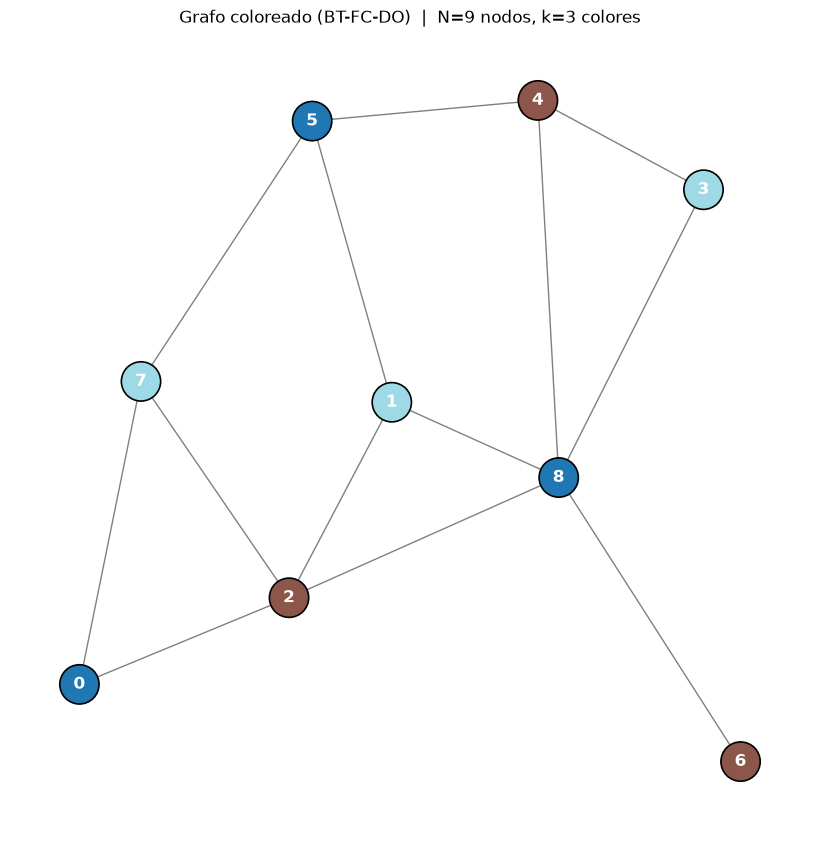

In [43]:
def visualizar_grafo_coloreado(matriz, solucion, titulo="Grafo coloreado (BT-FC-DO)"):
    """
    Dibuja el grafo definido por 'matriz' con sus nodos coloreados según
    'solucion' (diccionario {nodo: color}).
    """
    G = nx.from_numpy_array(matriz)

    num_colores = max(solucion.values()) + 1
    paleta = plt.colormaps.get_cmap('tab20').resampled(max(num_colores, 1))
    colores_nodos = [paleta(solucion[nodo]) for nodo in G.nodes()]

    pos = nx.spring_layout(G, seed=42)  # layout determinístico para reproducibilidad visual

    plt.figure(figsize=(8, 8))
    nx.draw(
        G, pos,
        with_labels=True,
        node_color=colores_nodos,
        node_size=800,
        edge_color='gray',
        linewidths=1.2,
        edgecolors='black',
        font_weight='bold',
        font_color='white'
    )
    plt.title(f"{titulo}  |  N={matriz.shape[0]} nodos, k={num_colores} colores")
    plt.axis('off')
    plt.show()


if solucion is not None:
    visualizar_grafo_coloreado(matriz_adyacencia, solucion)


## 6. Verificación de la solución

Como comprobación adicional, se valida que ningún par de nodos adyacentes comparta el mismo color.

In [44]:
def verificar_solucion(matriz, solucion):
    """Verifica que la solución cumpla la restricción del coloreado de grafos."""
    n = matriz.shape[0]
    for i in range(n):
        for j in range(n):
            if matriz[i][j] == 1 and solucion[i] == solucion[j]:
                return False, (i, j)
    return True, None

if solucion is not None:
    es_valida, conflicto = verificar_solucion(matriz_adyacencia, solucion)
    if es_valida:
        print("✔ La solución es válida: no hay nodos adyacentes con el mismo color.")
    else:
        print(f"✘ La solución NO es válida. Conflicto entre nodos {conflicto}.")


✔ La solución es válida: no hay nodos adyacentes con el mismo color.
